In [1]:
import os
import sys
import copy
import joblib

sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import torch

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import property_driven_ml.logics as logics
import property_driven_ml.training as training

from withProperties.attack_ import (
    DoSHttpFloodPostcondition,
    TabularRuleConstraint,
    PortscanPostcondition,
    GlobalBounds
)
from sklearn.model_selection import train_test_split
from utils.utils import *
from sklearn.preprocessing import MinMaxScaler
from utils.models import build_model
from specs import ATTACK_SPECS
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
TARGET_LABELS = ["BENIGN", "DOS_HTTP_FLOOD", "PORTSCAN"]
FEATURE_COLS = MODEL_NUMERIC_FEATURES + ENGINEERED_FEATURES

label_to_idx = {label: i for i, label in enumerate(TARGET_LABELS)}
idx = {name: i for i, name in enumerate(FEATURE_COLS)}

BOOLEAN_FEATURES = ["valid_tcp_handshake", "valid_http_conn"]

BATCH_SIZE = 1024
RANDOM_STATE = 42
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3

LAMBDA_DOS = 0.7
LAMBDA_SCAN = 1
PGD_STEPS = 10
PGD_RESTARTS = 1
PGD_STEP_SIZE = 0.01
PATIENCE = 5
MIN_DELTA = 1e-4

In [3]:
print(MODEL_NUMERIC_FEATURES)

['duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes']


In [4]:
print(FEATURE_COLS)

['duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'orig_pkt_rate', 'orig_byte_rate', 'time_elapsed', 'valid_tcp_handshake', 'valid_http_conn', 'uniq_dst_ports', 'pkts_per_port', 'scan_duration', 'fail_ratio']


In [5]:
raw_train_df = pd.read_csv("../data/ciciot2023_preprocessed_small.tsv", on_bad_lines="skip", delimiter="\t")
# raw_train_df = pd.read_csv("../data/cicids2017_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
# df_ciciot2023 = pd.read_csv("../data/ciciot2023_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
df_cicids2017 = pd.read_csv("../data/cicids2017_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
# df_ciciot2023_train = pd.read_csv("../data/ciciot2023_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
dataset_name = "CICIoT2023"
cross_eval_dataset_name = "CICIDS2017"

print_section("Loading data")
print_df_summary(raw_train_df, "Raw " + dataset_name + " train")

train_full_df = filter_labels(raw_train_df, TARGET_LABELS, label_to_idx)

print("Training set label distribution before split:")
print_label_distribution(train_full_df)

train_val_df, test_df = train_test_split(
    train_full_df,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=train_full_df["label"],
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=train_val_df["label"],
)


Loading data

Raw CICIoT2023 train summary
rows: 292,270
columns: 34

Label distribution:
ATTACK                count=  118708  ratio=0.4062
BENIGN                count=   34226  ratio=0.1171
DDOS_SYN_FLOOD        count=   74127  ratio=0.2536
DDOS_UDP_FLOOD        count=   29011  ratio=0.0993
DOS_HTTP_FLOOD        count=   14545  ratio=0.0498
PORTSCAN              count=   21653  ratio=0.0741
Training set label distribution before split:
BENIGN                count=   34226  ratio=0.4860
DOS_HTTP_FLOOD        count=   14545  ratio=0.2065
PORTSCAN              count=   21653  ratio=0.3075


# Scaling and Dataloaders

In [6]:
def make_loader(df: pd.DataFrame, feature_cols: list[str], batch_size: int = 1024, shuffle: bool = False) -> DataLoader:
    x = torch.tensor(df[feature_cols].to_numpy(), dtype=torch.float32)
    y = torch.tensor(df["label_id"].to_numpy(), dtype=torch.long)
    return DataLoader(TensorDataset(x, y), batch_size=batch_size, shuffle=shuffle)


def scale_value(col, raw_value, scaler, scale_cols):
    i = scale_cols.index(col)
    min_ = scaler.data_min_[i]
    max_ = scaler.data_max_[i]
    return (raw_value - min_) / (max_ - min_ + 1e-8)


def make_scaled_attack_specs(raw_specs: dict, scaler, scale_cols: list[str]) -> dict:
    specs = copy.deepcopy(raw_specs)
    scale_map = {
        "validity": {
            "valid_packet_size_min_pkts": "orig_pkts",
            "valid_packet_size_min_total_bytes": "orig_bytes",
        },
        "dos_http_flood": {
            "mal_time_elapsed_min": "time_elapsed",
            "mal_time_elapsed_max": "time_elapsed",
            "valid_pkt_size_total_min": "orig_bytes",
            "mal_byte_rate_min": "orig_byte_rate",
            "mal_pkt_rate_min": "orig_pkt_rate",
        },
        "portscan": {
            "min_uniq_dst_ports": "uniq_dst_ports",
            "max_pkts_per_port": "pkts_per_port",
            "max_scan_duration": "scan_duration",
            "min_fail_ratio": "fail_ratio",
        },
    }

    for attack_name, key_to_col in scale_map.items():
        for spec_key, col in key_to_col.items():
            specs[attack_name][spec_key] = scale_value(col, raw_specs[attack_name][spec_key], scaler, scale_cols)

    return specs

In [7]:
scale_cols = [col for col in FEATURE_COLS if col not in BOOLEAN_FEATURES]
scaler = MinMaxScaler()
# Clip outliers to the 1st and 99th percentiles before scaling
train_df[scale_cols] = train_df[scale_cols].clip(lower=train_df[scale_cols].quantile(0.01), upper=train_df[scale_cols].quantile(0.99), axis=1,)
test_df[scale_cols] = test_df[scale_cols].clip(lower=test_df[scale_cols].quantile(0.01), upper=test_df[scale_cols].quantile(0.99), axis=1,)
val_df[scale_cols] = val_df[scale_cols].clip(lower=val_df[scale_cols].quantile(0.01), upper=val_df[scale_cols].quantile(0.99), axis=1,)

train_df[scale_cols] = scaler.fit_transform(train_df[scale_cols])
test_df[scale_cols] = scaler.transform(test_df[scale_cols])
val_df[scale_cols] = scaler.transform(val_df[scale_cols])

scaled_attack_specs = make_scaled_attack_specs(ATTACK_SPECS, scaler, scale_cols)

train_loader = make_loader(train_df, FEATURE_COLS, batch_size=BATCH_SIZE, shuffle=True)
test_loader = make_loader(test_df, FEATURE_COLS, batch_size=BATCH_SIZE)
val_loader = make_loader(val_df, FEATURE_COLS, batch_size=BATCH_SIZE)

In [8]:
scaled_attack_specs["portscan"]

{'min_uniq_dst_ports': np.float64(0.019019019018828638),
 'max_pkts_per_port': np.float64(0.0013313609467435928),
 'max_scan_duration': np.float64(0.016284757934392165),
 'min_fail_ratio': np.float64(0.7499999925000002)}

In [9]:
train_df.head()

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,valid_http_conn,orig_pkt_rate,orig_byte_rate,window_id,is_failed_conn,uniq_dst_ports,pkts_per_port,scan_duration,fail_ratio,label_id
246119,1.659987e+09,CBnhSq2fzV4mrlCWkf,192.168.137.66,43804,192.168.137.211,8080,tcp,http,0.501405,0.355625,...,1,2.073971e-07,0.010147,331997433,1,0.000000,0.364941,0.270981,1.000000,1
267227,1.665164e+09,Cg0igo4tnpHK0bZMkk,192.168.137.41,52372,157.249.81.141,443,tcp,ssl,0.001895,0.006252,...,1,1.766165e-05,0.047205,333032798,0,0.002002,0.001627,0.000975,0.000000,0
238909,1.664211e+09,ClJwPg3o4FyxL8M8Uh,192.168.137.178,52469,192.168.137.206,60443,tcp,-,0.000274,0.000000,...,0,2.439624e-05,0.000000,332842105,1,1.000000,0.000000,0.000270,1.000000,2
266952,1.665177e+09,CrdmC13njFfuJ6dmF3,192.168.137.51,52574,192.168.137.1,53,udp,dns,0.000181,0.001096,...,0,3.692158e-05,0.086408,333035468,0,0.001001,0.000518,0.068365,0.333333,0
245995,1.659976e+09,Cd2Kcp4PR6heU5FiU6,192.168.137.66,47240,192.168.137.131,80,tcp,http,0.162227,0.626336,...,1,1.537420e-06,0.055234,331995183,1,0.000000,1.000000,0.466561,0.983264,1


# Setup model and constraints

In [10]:
logic = logics.DL2()

lower_bound = torch.zeros(len(FEATURE_COLS), device=device)
upper_bound = torch.ones(len(FEATURE_COLS), device=device)

model = build_model(
    model_type="mlp",
    n_features=len(FEATURE_COLS),
    num_classes=len(label_to_idx),
).to(device)

In [11]:
precondition=GlobalBounds(
    device=device,
    lower_bound=lower_bound,
    upper_bound=upper_bound
)

dos_constraint = TabularRuleConstraint(
    device,
    precondition=precondition,
    postcondition=DoSHttpFloodPostcondition(
        idx=idx,
        class_idx=label_to_idx["DOS_HTTP_FLOOD"],
        dos_http_flood_specs=scaled_attack_specs["dos_http_flood"],
        validity_specs=scaled_attack_specs["validity"],
        min_prob=0.8
    )
)

scan_constraint = TabularRuleConstraint(
    device,
    precondition=precondition,
    postcondition=PortscanPostcondition(
        idx=idx,
        class_idx=label_to_idx["PORTSCAN"],
        min_prob=0.8,
        portscan_specs=scaled_attack_specs["portscan"]
    )
)

## Train Helpers

In [12]:
def update_rule_stats_for_label(stats: dict, parts: dict, y: torch.Tensor, class_idx: int) -> None:
    label_mask = y == class_idx

    for name, mask in parts.items():
        filtered_mask = mask.detach().bool()[label_mask]
        stats.setdefault(name, {"true": 0, "total": 0})
        stats[name]["true"] += filtered_mask.sum().item()
        stats[name]["total"] += filtered_mask.numel()


def print_rule_stats(name: str, stats: dict) -> None:
    print(f"\n{name} rule debug - true-label rows only")

    for part_name, values in stats.items():
        true = values["true"]
        total = values["total"]
        print(f"{part_name:25s} {true:8d}/{total:<8d}  {true / max(total, 1):.4f}")


def make_weighted_ce_loss(train_df: pd.DataFrame, device: torch.device) -> nn.CrossEntropyLoss:
    class_counts = train_df["label_id"].value_counts().sort_index().to_numpy()
    class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
    class_weights = (class_weights / class_weights.mean()).to(device)

    print("class_counts:", class_counts)
    print("class_weights:", class_weights)
    return nn.CrossEntropyLoss(weight=class_weights)

In [13]:
def unscale_tensor_col(x_scaled, col, scaler, scale_cols):
    i = scale_cols.index(col)
    min_ = torch.tensor(scaler.data_min_[i], device=x_scaled.device, dtype=x_scaled.dtype)
    max_ = torch.tensor(scaler.data_max_[i], device=x_scaled.device, dtype=x_scaled.dtype)
    return x_scaled * (max_ - min_ + 1e-8) + min_


def scale_tensor_col(x_raw, col, scaler, scale_cols):
    i = scale_cols.index(col)
    min_ = torch.tensor(scaler.data_min_[i], device=x_raw.device, dtype=x_raw.dtype)
    max_ = torch.tensor(scaler.data_max_[i], device=x_raw.device, dtype=x_raw.dtype)
    return (x_raw - min_) / (max_ - min_ + 1e-8)


def recompute_rates_tensor(x_adv, idx, eps=1e-6):
    x_adv = x_adv.clone()

    duration_raw = unscale_tensor_col(
        x_adv[:, idx["duration"]],
        "duration",
        scaler,
        scale_cols,
    ).clamp(min=eps)

    orig_pkts_raw = unscale_tensor_col(
        x_adv[:, idx["orig_pkts"]],
        "orig_pkts",
        scaler,
        scale_cols,
    )

    orig_bytes_raw = unscale_tensor_col(
        x_adv[:, idx["orig_bytes"]],
        "orig_bytes",
        scaler,
        scale_cols,
    )

    orig_pkt_rate_raw = orig_pkts_raw / duration_raw
    orig_byte_rate_raw = orig_bytes_raw / duration_raw

    x_adv[:, idx["orig_pkt_rate"]] = scale_tensor_col(
        orig_pkt_rate_raw,
        "orig_pkt_rate",
        scaler,
        scale_cols,
    )

    x_adv[:, idx["orig_byte_rate"]] = scale_tensor_col(
        orig_byte_rate_raw,
        "orig_byte_rate",
        scaler,
        scale_cols,
    )

    return x_adv

@torch.no_grad()
def rule_mask(constraint, model, x, y, class_idx):
    parts = constraint.postcondition.debug_parts(model, x, x)
    return (y == class_idx) & parts["antecedent_true"]

# Training

In [14]:
dos_class = label_to_idx["DOS_HTTP_FLOOD"]
scan_class = label_to_idx["PORTSCAN"]

In [15]:
from sklearn.metrics import f1_score

def train_one_epoch(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    grad_norm: training.GradNorm,
    oracle: training.PGD,
    logic,
    ce_fn,
    epoch_num: int,
) -> dict:
    model.train()
    totals = {"ce_loss": 0.0, "scaled_dos_loss": 0.0, "scaled_scan_loss": 0.0, "dos_sat": 0.0, "scan_sat": 0.0}
    dos_debug_stats, scan_debug_stats = {}, {}

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        ce_loss = ce_fn(logits, y)

        constraint_loss = torch.tensor(0.0, device=device)

        # -------------------------
        # DoS property
        # -------------------------:
        dos_mask = rule_mask(dos_constraint, model, x, y, dos_class)
        if dos_mask.any():
            x_dos = x[dos_mask]
            y_dos = y[dos_mask]
            x_adv_dos = oracle.attack(model, x_dos, None, dos_constraint)
            x_adv_dos = torch.clamp(x_adv_dos, min=lower_bound, max=upper_bound)
            x_adv_dos = recompute_rates_tensor(x_adv_dos, idx)

            dos_loss, dos_sat = dos_constraint.eval(
                model,
                x_dos,
                x_adv_dos,
                None,
                logic,
                reduction="mean",
            )

            constraint_loss = constraint_loss + LAMBDA_DOS * dos_loss

            totals["scaled_dos_loss"] += LAMBDA_DOS * dos_loss.item()
            totals["dos_sat"] += dos_sat.item()

            with torch.no_grad():
                update_rule_stats_for_label(
                    dos_debug_stats,
                    dos_constraint.postcondition.debug_parts(
                        model, x_dos, x_adv_dos
                    ),
                    y_dos,
                    dos_class,
                )

        # -------------------------
        # Portscan property
        # -------------------------
        scan_mask = rule_mask(scan_constraint, model, x, y, scan_class)
        if scan_mask.any():
            x_scan = x[scan_mask]
            y_scan = y[scan_mask]
            x_adv_scan = oracle.attack(model, x_scan , None, scan_constraint)
            x_adv_scan = torch.clamp(x_adv_scan, min=lower_bound, max=upper_bound)
            x_adv_scan = recompute_rates_tensor(x_adv_scan, idx)

            scan_loss, scan_sat = scan_constraint.eval(
                model,
                x_scan,
                x_adv_scan,
                None,
                logic,
                reduction="mean",
            )

            constraint_loss = constraint_loss + LAMBDA_SCAN * scan_loss

            totals["scaled_scan_loss"] += LAMBDA_SCAN * scan_loss.item()
            totals["scan_sat"] += scan_sat.item()

            with torch.no_grad():
                update_rule_stats_for_label(
                    scan_debug_stats,
                    scan_constraint.postcondition.debug_parts(
                        model, x_scan, x_adv_scan
                    ),
                    y_scan,
                    scan_class,
                )

        # -------------------------
        # Backprop
        # -------------------------
        if (epoch_num > 3) & (constraint_loss is not None):
            grad_norm.balance(ce_loss, constraint_loss)
        else:
            ce_loss.backward()
            optimizer.step()

        totals["ce_loss"] += ce_loss.item()

    batches = len(train_loader)
    metrics = {key: value / batches for key, value in totals.items()}
    metrics["dos_debug_stats"] = dos_debug_stats
    metrics["scan_debug_stats"] = scan_debug_stats
    return metrics


@torch.no_grad()
def evaluate_epoch_split(model: nn.Module, loader: DataLoader) -> dict:
    model.eval()

    y_true, y_pred = [], []

    dos_loss_total = 0.0
    scan_loss_total = 0.0
    dos_sat_total = 0.0
    scan_sat_total = 0.0

    dos_count = 0
    scan_count = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        preds = logits.argmax(dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

        dos_mask = rule_mask(dos_constraint, model, x, y, dos_class)

        if dos_mask.any():
            x_dos = x[dos_mask]

            dos_loss, dos_sat = dos_constraint.eval(
                model,
                x_dos,
                x_dos,
                None,
                logic,
                reduction="sum",
            )

            dos_loss_total += dos_loss.item()
            dos_sat_total += dos_sat.item()
            dos_count += x_dos.size(0)

        scan_mask = rule_mask(scan_constraint, model, x, y, scan_class)

        if scan_mask.any():
            x_scan = x[scan_mask]

            scan_loss, scan_sat = scan_constraint.eval(
                model,
                x_scan,
                x_scan,
                None,
                logic,
                reduction="sum",
            )

            scan_loss_total += scan_loss.item()
            scan_sat_total += scan_sat.item()
            scan_count += x_scan.size(0)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    attack_ids = [label_to_idx[label] for label in TARGET_LABELS[1:]]

    return {
        "acc": float((y_true == y_pred).mean()),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "attack_macro_f1": f1_score(
            y_true,
            y_pred,
            labels=attack_ids,
            average="macro",
            zero_division=0,
        ),

        "dos_sat": dos_sat_total / max(dos_count, 1),
        "scan_sat": scan_sat_total / max(scan_count, 1),
        "dos_loss": dos_loss_total / max(dos_count, 1),
        "scan_loss": scan_loss_total / max(scan_count, 1),
    }

In [16]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
grad_norm = training.GradNorm(model, device, optimizer, lr=LEARNING_RATE, alpha=1.5)
oracle = training.PGD(logic, device, steps=PGD_STEPS, restarts=PGD_RESTARTS, step_size=PGD_STEP_SIZE)
ce_fn = make_weighted_ce_loss(train_df, device=device)

PGD steps=10 restarts=1 step_size=tensor([0.0100], device='cuda:0')
class_counts: [19166  8145 12125]
class_weights: tensor([0.6081, 1.4308, 0.9611], device='cuda:0')


In [17]:
def model_selection_score(metrics: dict) -> float:
    return (
        2.0 * metrics["attack_macro_f1"]
        + 0.5 * metrics["macro_f1"]
        + 0.5 * metrics["dos_sat"]
        + 0.5 * metrics["scan_sat"]
        + 0.5 * metrics["acc"]
    )

In [18]:
best_score = -float("inf") 
best_state = None 
best_epoch = 0 
epochs_without_improvement = 0 
history = [] 

for epoch in range(1, NUM_EPOCHS + 1): 
    train_metrics = train_one_epoch( 
        model=model, 
        optimizer=optimizer, 
        grad_norm=grad_norm,
        oracle=oracle, 
        logic=logic, 
        ce_fn=ce_fn,
        epoch_num=epoch
    )
    val_metrics = evaluate_epoch_split(model, val_loader) 
    score = model_selection_score(val_metrics) 
    history.append({ 
        "epoch": epoch, 
        **{f"train_{k}": v for k, v in train_metrics.items() if not k.endswith("_stats")}, 
        **{f"val_{k}": v for k, v in val_metrics.items()}, "selection_score": score 
    }) 
    
    if score > best_score + MIN_DELTA: 
        best_score = score 
        best_epoch = epoch 
        best_state = copy.deepcopy(model.state_dict()) 
        epochs_without_improvement = 0 
    else: 
        epochs_without_improvement += 1 
        
    print( 
        f"epoch={epoch} \n" 
        f"----- TRAIN -----\n" 
        f"ce_loss={train_metrics['ce_loss']:.4f} " 
        f"scaled_dos_loss={train_metrics['scaled_dos_loss']:.4f} " 
        f"scaled_scan_loss={train_metrics['scaled_scan_loss']:.4f} " 
        f"dos_sat={train_metrics['dos_sat']:.4f} " 
        f"scan_sat={train_metrics['scan_sat']:.4f} \n " 
        f"----- VALIDATION -----\n" f"attack_f1={val_metrics['attack_macro_f1']:.4f} " 
        f"acc={val_metrics['acc']:.4f} " 
        f"dos_loss={val_metrics['dos_loss']:.4f} " 
        f"dos_sat={val_metrics['dos_sat']:.4f} " 
        f"scan_loss={val_metrics['scan_loss']:.4f} " 
        f"scan_sat={val_metrics['scan_sat']:.4f} \n" 
        f"score={score:.4f}" ) 
    print_rule_stats("DoS HTTP Flood", train_metrics["dos_debug_stats"]) 
    print_rule_stats("Portscan", train_metrics["scan_debug_stats"]) 
    
    if epochs_without_improvement >= PATIENCE: 
        print(f"Early stopping at epoch={epoch}. Best epoch={best_epoch}, best_score={best_score:.4f}") 
        break

epoch=1 
----- TRAIN -----
ce_loss=0.5695 scaled_dos_loss=0.3245 scaled_scan_loss=0.6471 dos_sat=0.3064 scan_sat=0.0929 
 ----- VALIDATION -----
attack_f1=0.8578 acc=0.8639 dos_loss=0.0287 dos_sat=0.9392 scan_loss=0.0279 scan_sat=0.9120 
score=3.5053

DoS HTTP Flood rule debug - true-label rows only
valid_input                  48746/48746     1.0000
valid_tcp_handshake          48746/48746     1.0000
valid_http_conn              48746/48746     1.0000
mal_time_elapsed_min         48746/48746     1.0000
mal_time_elapsed_max         48746/48746     1.0000
valid_pkt_size_total_min     48746/48746     1.0000
mal_byte_rate_min            48734/48746     0.9998
mal_pkt_rate_min              7332/48746     0.1504
prediction_ok                14938/48746     0.3064
antecedent_true              48746/48746     1.0000

Portscan rule debug - true-label rows only
min_uniq_dst_ports           80423/80423     1.0000
min_fail_ratio               80423/80423     1.0000
max_pkts_per_port            80

In [19]:
model.load_state_dict(best_state)

test_metrics = evaluate_epoch_split(model, test_loader)

print(
    f"----- FINAL TEST | best_epoch={best_epoch} -----\n"
    f"attack_f1={test_metrics['attack_macro_f1']:.4f} "
    f"macro_f1={test_metrics['macro_f1']:.4f} "
    f"acc={test_metrics['acc']:.4f} "
    f"dos_loss={test_metrics['dos_loss']:.4f} "
    f"dos_sat={test_metrics['dos_sat']:.4f} "
    f"scan_loss={test_metrics['scan_loss']:.4f} "
    f"scan_sat={test_metrics['scan_sat']:.4f}"
)

----- FINAL TEST | best_epoch=4 -----
attack_f1=0.8901 macro_f1=0.8920 acc=0.8886 dos_loss=0.0331 dos_sat=0.9542 scan_loss=0.0038 scan_sat=0.9842


In [18]:
def save_property_model(
    model,
    save_path,
    features,
    model_type,
    scaler
):
    joblib.dump(
        {
            "model": model.cpu(),
            "features": features,
            "model_type": model_type,
            "scaler": scaler
        },
        save_path,
    )

    print(f"Saved model to: {save_path}")

In [21]:
save_property_model(
    model,
    f"models/property_model_{dataset_name.lower()}_3_classes.joblib",
    features=FEATURE_COLS,
    model_type="mlp",
    scaler=scaler,
)

Saved model to: models/property_model_ciciot2023_3_classes.joblib


# Evaluate cross-data

In [19]:
def prepare_eval_df(
    df: pd.DataFrame,
    target_labels: list[str],
    label_to_idx: dict[str, int],
    scaler: MinMaxScaler
) -> pd.DataFrame:
    df = filter_labels(df, target_labels, label_to_idx)
    df[scale_cols] = scaler.transform(df[scale_cols])
    return df


cross_eval_df = prepare_eval_df(df_cicids2017, TARGET_LABELS, label_to_idx, scaler)

In [20]:
@torch.no_grad()
def evaluate_model_metrics(
    model: nn.Module,
    df: pd.DataFrame,
    batch_size: int = 1024,
) -> tuple[dict, pd.DataFrame, np.ndarray, list[str]]:
    loader = make_loader(df, FEATURE_COLS, batch_size=batch_size)
    idx_to_label = {v: k for k, v in label_to_idx.items()}
    label_ids = list(range(len(idx_to_label)))
    labels = [idx_to_label[i] for i in label_ids]

    model = model.to(device)
    model.eval()

    y_true, y_pred = [], []
    totals = {"dos_loss": 0.0, "scan_loss": 0.0, "dos_sat": 0.0, "scan_sat": 0.0}
    dos_debug_stats, scan_debug_stats = {}, {}
    n = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        preds = logits.argmax(dim=1)

        dos_loss, dos_sat = dos_constraint.eval(model, x, x, None, logic, reduction="sum")
        scan_loss, scan_sat = scan_constraint.eval(model, x, x, None, logic, reduction="sum")

        update_rule_stats_for_label(
            dos_debug_stats,
            dos_constraint.postcondition.debug_parts(model, x, x),
            y,
            label_to_idx["DOS_HTTP_FLOOD"],
        )
        update_rule_stats_for_label(
            scan_debug_stats,
            scan_constraint.postcondition.debug_parts(model, x, x),
            y,
            label_to_idx["PORTSCAN"],
        )

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

        totals["dos_loss"] += dos_loss.item()
        totals["scan_loss"] += scan_loss.item()
        totals["dos_sat"] += dos_sat.item()
        totals["scan_sat"] += scan_sat.item()
        n += x.size(0)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    report = classification_report(
        y_true,
        y_pred,
        labels=label_ids,
        target_names=labels,
        digits=4,
        zero_division=0,
        output_dict=True,
    )

    for label_id, label_name in zip(label_ids, labels):
        mask = y_true == label_id
        report[label_name]["accuracy"] = float((y_pred[mask] == label_id).mean()) if mask.sum() else 0.0

    metrics = {
        "acc": float((y_true == y_pred).mean()),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "dos_loss": totals["dos_loss"] / max(n, 1),
        "scan_loss": totals["scan_loss"] / max(n, 1),
        "dos_sat": totals["dos_sat"] / max(n, 1),
        "scan_sat": totals["scan_sat"] / max(n, 1),
    }

    print_rule_stats("Cross-dataset DoS HTTP Flood", dos_debug_stats)
    print_rule_stats("Cross-dataset Portscan", scan_debug_stats)

    cm = confusion_matrix(y_true, y_pred, labels=label_ids)
    return metrics, pd.DataFrame(report).T, cm, labels

In [24]:
metrics, report_df, cm, labels = evaluate_model_metrics(
    model,
    cross_eval_df
)


Cross-dataset DoS HTTP Flood rule debug - true-label rows only
valid_input                 155349/155349    1.0000
valid_tcp_handshake         154659/155349    0.9956
valid_http_conn             155349/155349    1.0000
mal_time_elapsed_min        155349/155349    1.0000
mal_time_elapsed_max        155348/155349    1.0000
valid_pkt_size_total_min    155349/155349    1.0000
mal_byte_rate_min           153026/155349    0.9850
mal_pkt_rate_min            152953/155349    0.9846
prediction_ok               150758/155349    0.9704
antecedent_true             152970/155349    0.9847

Cross-dataset Portscan rule debug - true-label rows only
min_uniq_dst_ports          153030/154034    0.9935
min_fail_ratio              153195/154034    0.9946
max_pkts_per_port           153932/154034    0.9993
max_scan_duration           139771/154034    0.9074
prediction_ok               152751/154034    0.9917
scan_signal                 153968/154034    0.9996
antecedent_true             152986/154034    0

In [ ]:
from pathlib import Path


def plot_eval_summary(metrics, report_df, cm, labels, model_name, save_path=None):
    fig, (ax1, ax2, ax3) = plt.subplots(
        3,
        1,
        figsize=(11, 15),
        gridspec_kw={"height_ratios": [3, 1.2, 2.8]},
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax1,
    )
    ax1.set_xlabel("Predicted")
    ax1.set_ylabel("Actual")
    ax1.set_title(f"{model_name} Confusion Matrix")

    ax2.axis("off")
    metrics_text = "\n".join(
        [
            f"accuracy: {metrics['acc']:.3f}",
            f"macro_f1: {metrics['macro_f1']:.3f}",
            f"dos_loss: {metrics['dos_loss']:.3f}",
            f"scan_loss: {metrics['scan_loss']:.3f}",
            f"dos_sat: {metrics['dos_sat']:.3f}",
            f"scan_sat: {metrics['scan_sat']:.3f}",
        ]
    )
    ax2.text(
        0.01,
        0.95,
        metrics_text,
        va="top",
        ha="left",
        family="monospace",
        fontsize=11,
    )

    ax3.axis("off")
    ax3.text(
        0.01,
        0.95,
        report_df.round(3).to_string(),
        va="top",
        ha="left",
        family="monospace",
        fontsize=9,
    )
    ax3.set_title("Classification Report + Per-Label Accuracy")
    if save_path is not None:
        save_path = Path(save_path)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {save_path}")

    plt.tight_layout()
    plt.show()
    return fig

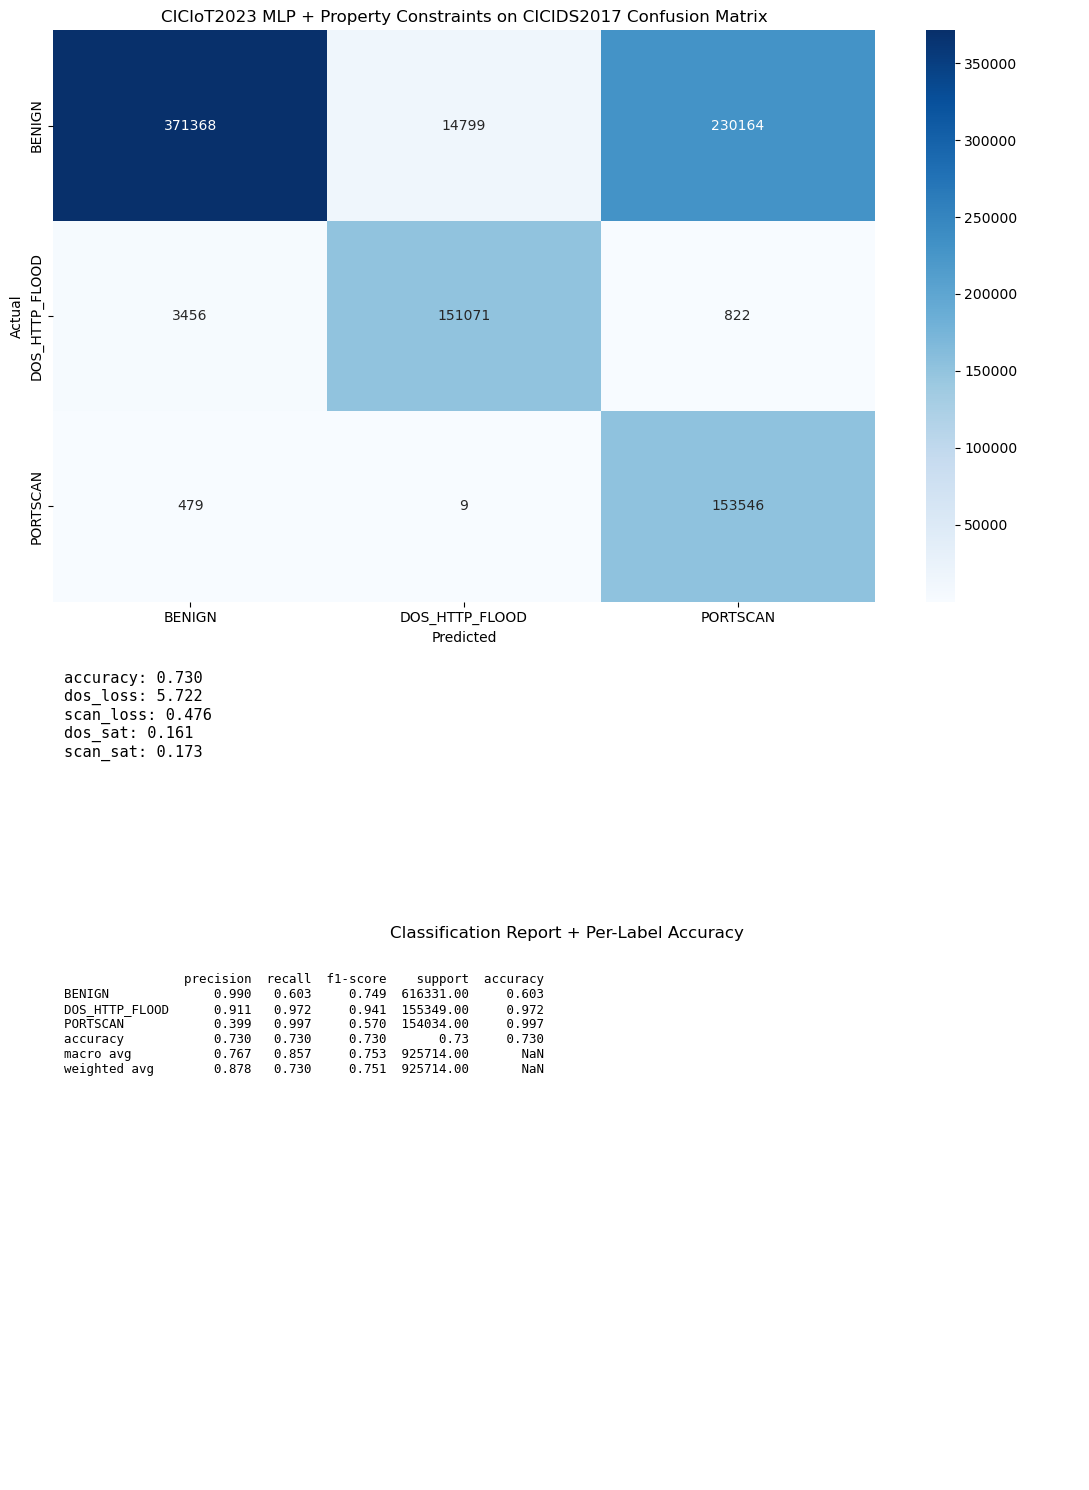

In [26]:
plot_eval_summary(
    metrics,
    report_df,
    cm,
    labels,
    model_name=f"{dataset_name} MLP + Property Constraints on {cross_eval_dataset_name}",
)

# Grid-Serach (takes a long time!)

In [ ]:
BATCH_SIZES = [524, 1024]
LEARNING_RATES = [0.001, 0.0005, 0.0001]
LAMBDA_DOS_LIST = [0.25, 0.5, 0.75, 1.0]
LAMBDA_SCANS = [0.25, 0.5, 0.75, 1.0]
PGD_STEPS_LIST = [3, 5]
PGD_STEP_SIZE_LIST = [0.001, 0.01]

In [23]:
from itertools import product
from pathlib import Path
import json
import time

RESULTS_DIR = Path("grid_results")
RESULTS_DIR.mkdir(exist_ok=True)

all_results = []
best_score = -float("inf")
best_result = None
best_state = None

In [24]:
def combined_generalization_score(own_metrics: dict, cross_metrics: dict) -> float:
    return (
        0.2 * own_metrics["macro_f1"]
        + 0.2 * own_metrics["acc"]
        + 0.5 * cross_metrics["macro_f1"]
        + 0.3 * cross_metrics["acc"]
    )

In [25]:
def make_run_id(params):
    return (
        f"bs{params['batch_size']}_"
        f"lr{params['learning_rate']}_"
        f"ldos{params['lambda_dos']}_"
        f"lscan{params['lambda_scan']}_"
        f"pgd{params['pgd_steps']}_"
        f"step{params['pgd_step_size']}"
    )

In [ ]:
def run_single_config(params):
    global train_loader, val_loader, test_loader
    global LAMBDA_DOS, LAMBDA_SCAN

    run_id = make_run_id(params)
    print(f"\n========== RUN {run_id} ==========")

    # -------------------------
    # Set hyperparameters
    # -------------------------
    LAMBDA_DOS = params["lambda_dos"]
    LAMBDA_SCAN = params["lambda_scan"]

    train_loader = make_loader(
        train_df,
        FEATURE_COLS,
        batch_size=params["batch_size"],
        shuffle=True,
    )

    val_loader = make_loader(
        val_df,
        FEATURE_COLS,
        batch_size=params["batch_size"],
        shuffle=False,
    )

    test_loader = make_loader(
        test_df,
        FEATURE_COLS,
        batch_size=params["batch_size"],
        shuffle=False,
    )

    # -------------------------
    # Fresh model per run
    # -------------------------
    model = build_model(
        model_type="mlp",
        n_features=len(FEATURE_COLS),
        num_classes=len(label_to_idx),
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=params["learning_rate"],
    )

    grad_norm = training.GradNorm(
        model,
        device,
        optimizer,
        lr=params["learning_rate"],
        alpha=1.5,
    )

    oracle = training.PGD(
        logic,
        device,
        steps=params["pgd_steps"],
        restarts=PGD_RESTARTS,
        step_size=params["pgd_step_size"],
    )

    ce_fn = make_weighted_ce_loss(train_df, device=device)

    # -------------------------
    # Train with early stopping
    # -------------------------
    best_val_score = -float("inf")
    best_state = None
    best_epoch = 0
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, NUM_EPOCHS + 1):
        train_metrics = train_one_epoch(
            model=model,
            optimizer=optimizer,
            grad_norm=grad_norm,
            oracle=oracle,
            logic=logic,
            ce_fn=ce_fn,
            epoch_num=epoch,
        )

        val_metrics = evaluate_epoch_split(model, val_loader)
        val_score = model_selection_score(val_metrics)

        history.append({
            "epoch": epoch,
            **{
                f"train_{k}": v
                for k, v in train_metrics.items()
                if not k.endswith("_stats")
            },
            **{f"val_{k}": v for k, v in val_metrics.items()},
            "val_score": val_score,
        })

        if val_score > best_val_score + MIN_DELTA:
            best_val_score = val_score
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"run={run_id} epoch={epoch} "
            f"val_attack_f1={val_metrics['attack_macro_f1']:.4f} "
            f"val_acc={val_metrics['acc']:.4f} "
            f"val_score={val_score:.4f}"
        )

        if epochs_without_improvement >= PATIENCE:
            break

    model.load_state_dict(best_state)

    # -------------------------
    # Final own-test evaluation
    # -------------------------
    own_test_metrics = evaluate_epoch_split(model, test_loader)

    # -------------------------
    # Final cross-dataset evaluation
    # -------------------------
    cross_metrics, cross_report_df, cross_cm, cross_labels = evaluate_model_metrics(
        model,
        cross_eval_df,
        batch_size=params["batch_size"],
    )

    cross_cmfig = plot_eval_summary(
        cross_metrics,
        cross_report_df,
        cross_cm,
        cross_labels,
        model_name=f"{dataset_name}_{run_id} MLP + Property Constraints on {cross_eval_dataset_name}",
        save_path=RESULTS_DIR / f"{run_id}_conf_mat.png",
    )

    final_score = combined_generalization_score(
        own_test_metrics,
        cross_metrics,
    )

    result = {
        "run_id": run_id,
        "params": params,
        "best_epoch": best_epoch,
        "best_val_score": best_val_score,

        "own_test_acc": own_test_metrics["acc"],
        "own_test_macro_f1": own_test_metrics["macro_f1"],
        "own_test_dos_sat": own_test_metrics["dos_sat"],
        "own_test_scan_sat": own_test_metrics["scan_sat"],
        "own_test_dos_loss": own_test_metrics["dos_loss"],
        "own_test_scan_loss": own_test_metrics["scan_loss"],

        "cross_acc": cross_metrics["acc"],
        "cross_macro_f1": cross_metrics["macro_f1"],
        "cross_dos_sat": cross_metrics["dos_sat"],
        "cross_scan_sat": cross_metrics["scan_sat"],
        "cross_dos_loss": cross_metrics["dos_loss"],
        "cross_scan_loss": cross_metrics["scan_loss"],

        "final_score": final_score,
        "cross_cmfig": cross_cmfig,
    }

    # Save per-run artifacts
    pd.DataFrame(history).to_csv(
        RESULTS_DIR / f"{run_id}_history.csv",
        index=False,
    )

    save_property_model(
        model,
        RESULTS_DIR / f"{run_id}_model.joblib",
        features=FEATURE_COLS,
        model_type="mlp",
        scaler=scaler,
    )

    return result, best_state


========== RUN bs524_lr0.001_ldos0.25_lscan0.25_pgd3_step0.001 ==========
PGD steps=3 restarts=1 step_size=tensor([0.0010], device='cuda:0')
class_counts: [19166  8145 12125]
class_weights: tensor([0.6081, 1.4308, 0.9611], device='cuda:0')
run=bs524_lr0.001_ldos0.25_lscan0.25_pgd3_step0.001 epoch=1 val_attack_f1=0.8617 val_acc=0.8461 val_score=3.4969
run=bs524_lr0.001_ldos0.25_lscan0.25_pgd3_step0.001 epoch=2 val_attack_f1=0.8468 val_acc=0.8018 val_score=3.4487
run=bs524_lr0.001_ldos0.25_lscan0.25_pgd3_step0.001 epoch=3 val_attack_f1=0.5332 val_acc=0.4405 val_score=2.1236
run=bs524_lr0.001_ldos0.25_lscan0.25_pgd3_step0.001 epoch=4 val_attack_f1=0.4044 val_acc=0.6026 val_score=1.8575
run=bs524_lr0.001_ldos0.25_lscan0.25_pgd3_step0.001 epoch=5 val_attack_f1=0.7906 val_acc=0.7127 val_score=3.2723
run=bs524_lr0.001_ldos0.25_lscan0.25_pgd3_step0.001 epoch=6 val_attack_f1=0.7813 val_acc=0.7792 val_score=3.0559

Cross-dataset DoS HTTP Flood rule debug - true-label rows only
valid_input      

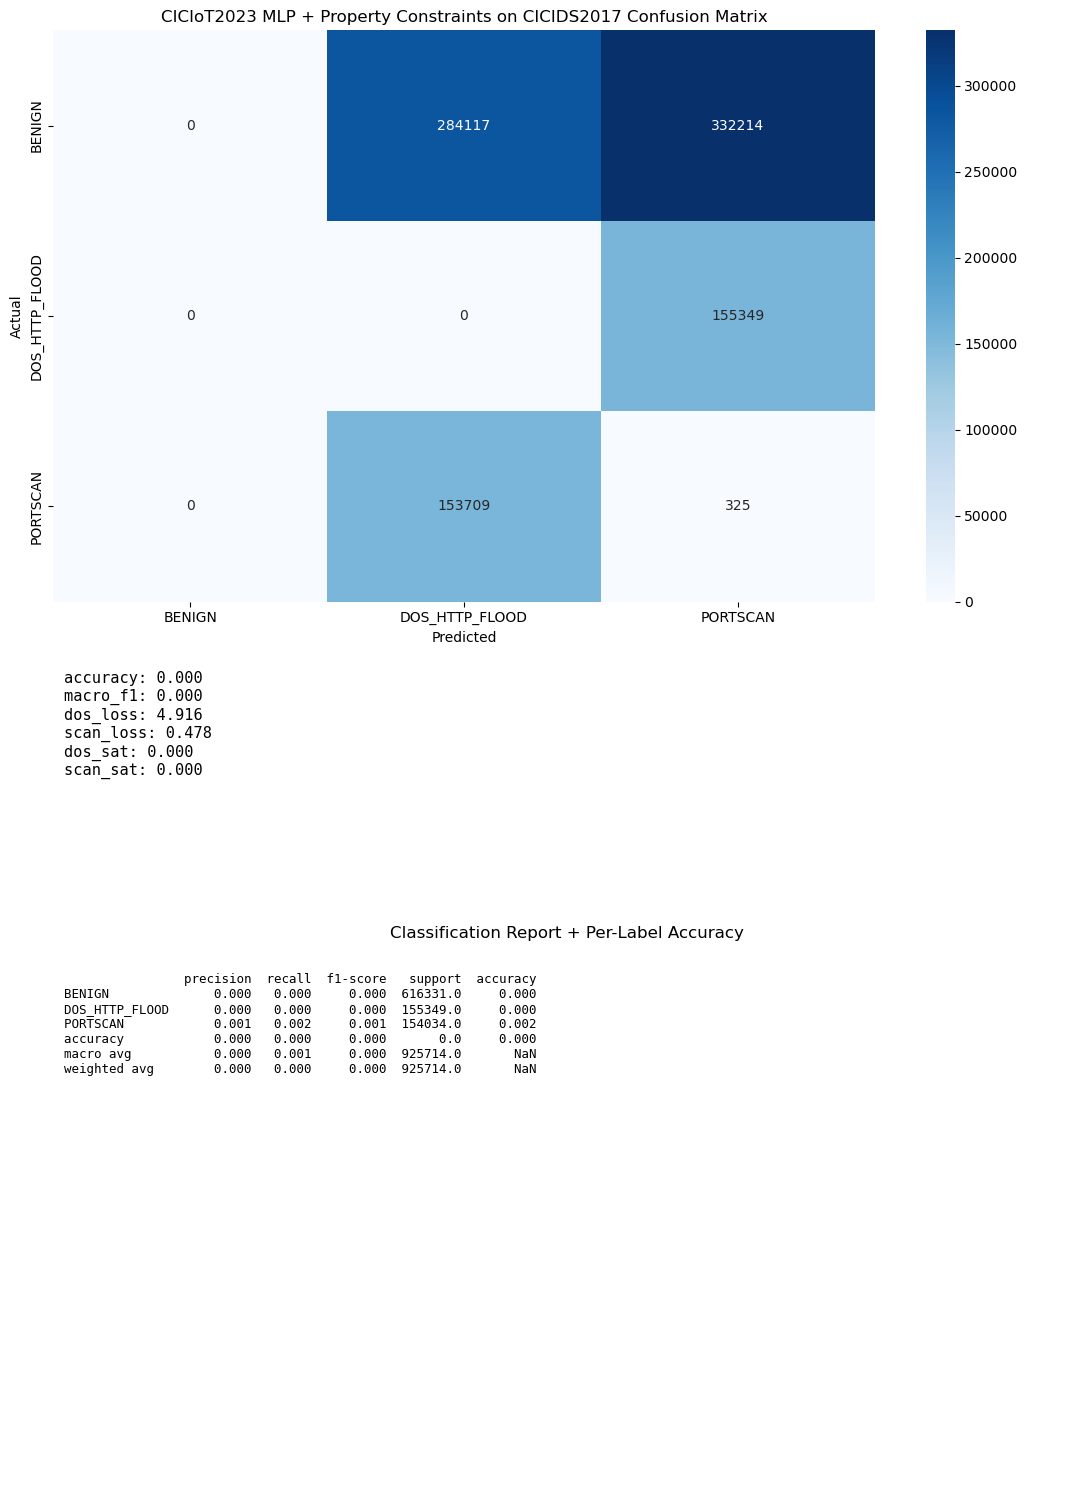


========== RUN bs524_lr0.001_ldos0.25_lscan0.25_pgd3_step0.01 ==========
PGD steps=3 restarts=1 step_size=tensor([0.0100], device='cuda:0')
class_counts: [19166  8145 12125]
class_weights: tensor([0.6081, 1.4308, 0.9611], device='cuda:0')
run=bs524_lr0.001_ldos0.25_lscan0.25_pgd3_step0.01 epoch=1 val_attack_f1=0.8090 val_acc=0.7796 val_score=3.2833
run=bs524_lr0.001_ldos0.25_lscan0.25_pgd3_step0.01 epoch=2 val_attack_f1=0.8320 val_acc=0.8433 val_score=3.3498
run=bs524_lr0.001_ldos0.25_lscan0.25_pgd3_step0.01 epoch=3 val_attack_f1=0.6812 val_acc=0.7100 val_score=2.9013
run=bs524_lr0.001_ldos0.25_lscan0.25_pgd3_step0.01 epoch=4 val_attack_f1=0.7238 val_acc=0.5209 val_score=2.8424
run=bs524_lr0.001_ldos0.25_lscan0.25_pgd3_step0.01 epoch=5 val_attack_f1=0.7859 val_acc=0.8086 val_score=3.1985
run=bs524_lr0.001_ldos0.25_lscan0.25_pgd3_step0.01 epoch=6 val_attack_f1=0.7613 val_acc=0.7982 val_score=3.1865
run=bs524_lr0.001_ldos0.25_lscan0.25_pgd3_step0.01 epoch=7 val_attack_f1=0.8667 val_acc=

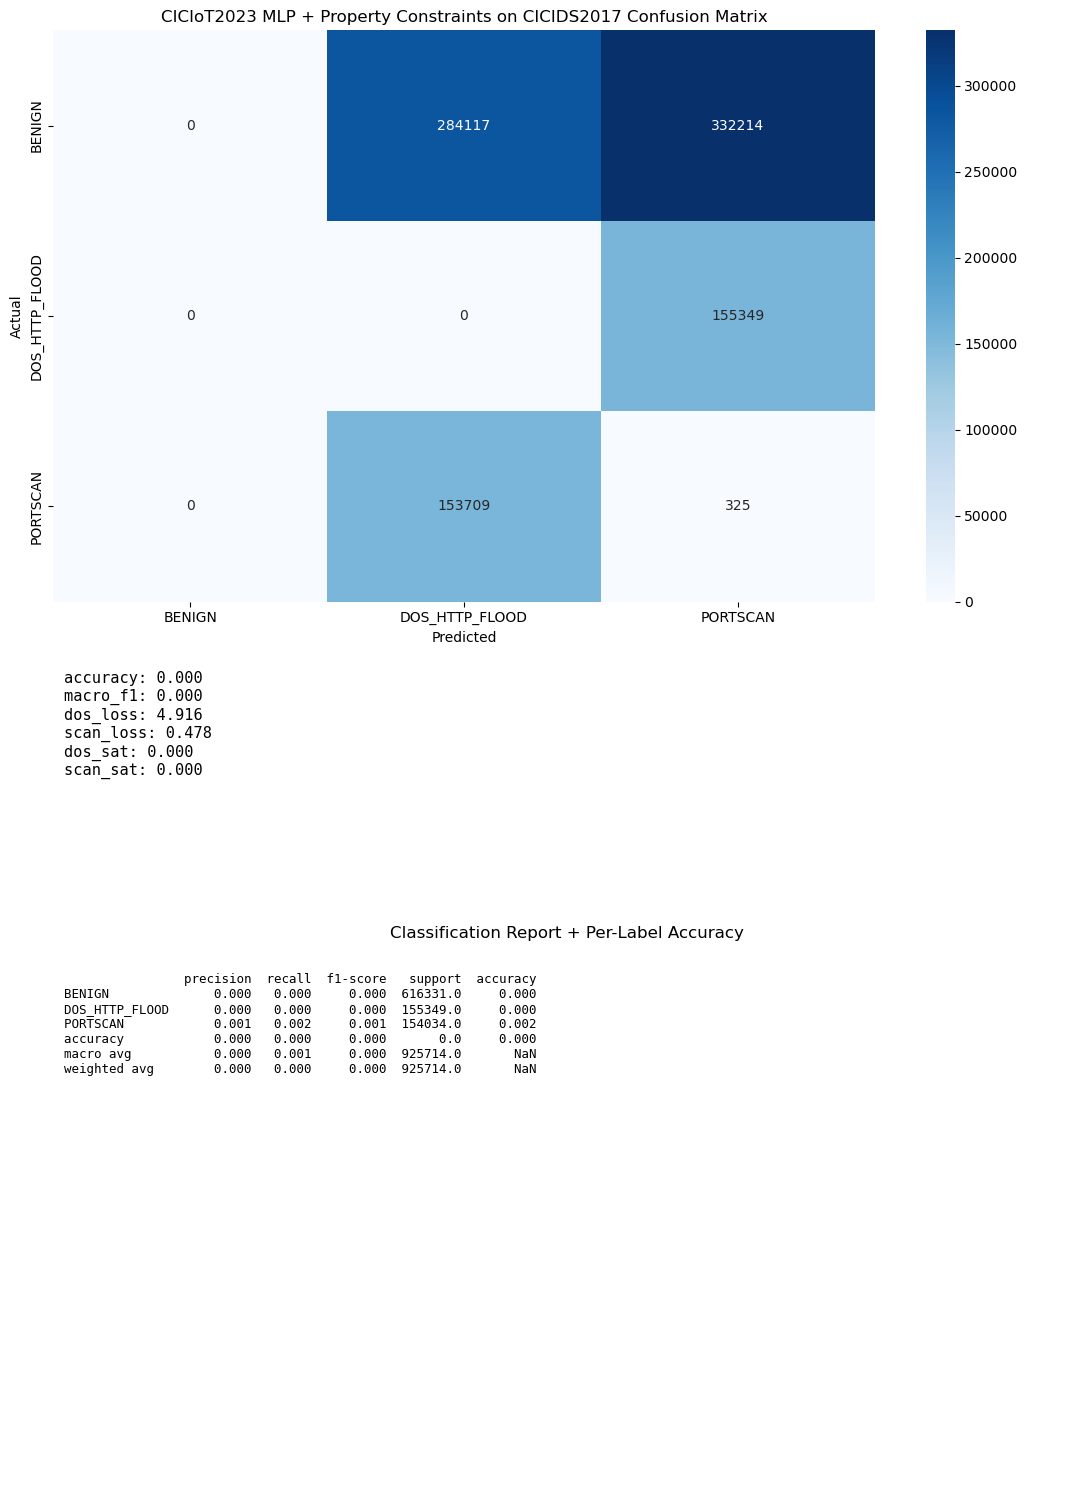


========== RUN bs524_lr0.0005_ldos0.25_lscan0.75_pgd3_step0.001 ==========
PGD steps=3 restarts=1 step_size=tensor([0.0010], device='cuda:0')
class_counts: [19166  8145 12125]
class_weights: tensor([0.6081, 1.4308, 0.9611], device='cuda:0')
run=bs524_lr0.0005_ldos0.25_lscan0.75_pgd3_step0.001 epoch=1 val_attack_f1=0.7683 val_acc=0.7439 val_score=2.4533
run=bs524_lr0.0005_ldos0.25_lscan0.75_pgd3_step0.001 epoch=2 val_attack_f1=0.8678 val_acc=0.8438 val_score=3.5147
run=bs524_lr0.0005_ldos0.25_lscan0.75_pgd3_step0.001 epoch=3 val_attack_f1=0.8454 val_acc=0.8328 val_score=3.4226
run=bs524_lr0.0005_ldos0.25_lscan0.75_pgd3_step0.001 epoch=4 val_attack_f1=0.8665 val_acc=0.8699 val_score=3.4886
run=bs524_lr0.0005_ldos0.25_lscan0.75_pgd3_step0.001 epoch=5 val_attack_f1=0.8073 val_acc=0.8163 val_score=3.3435
run=bs524_lr0.0005_ldos0.25_lscan0.75_pgd3_step0.001 epoch=6 val_attack_f1=0.8711 val_acc=0.8690 val_score=3.5160
run=bs524_lr0.0005_ldos0.25_lscan0.75_pgd3_step0.001 epoch=7 val_attack_f1

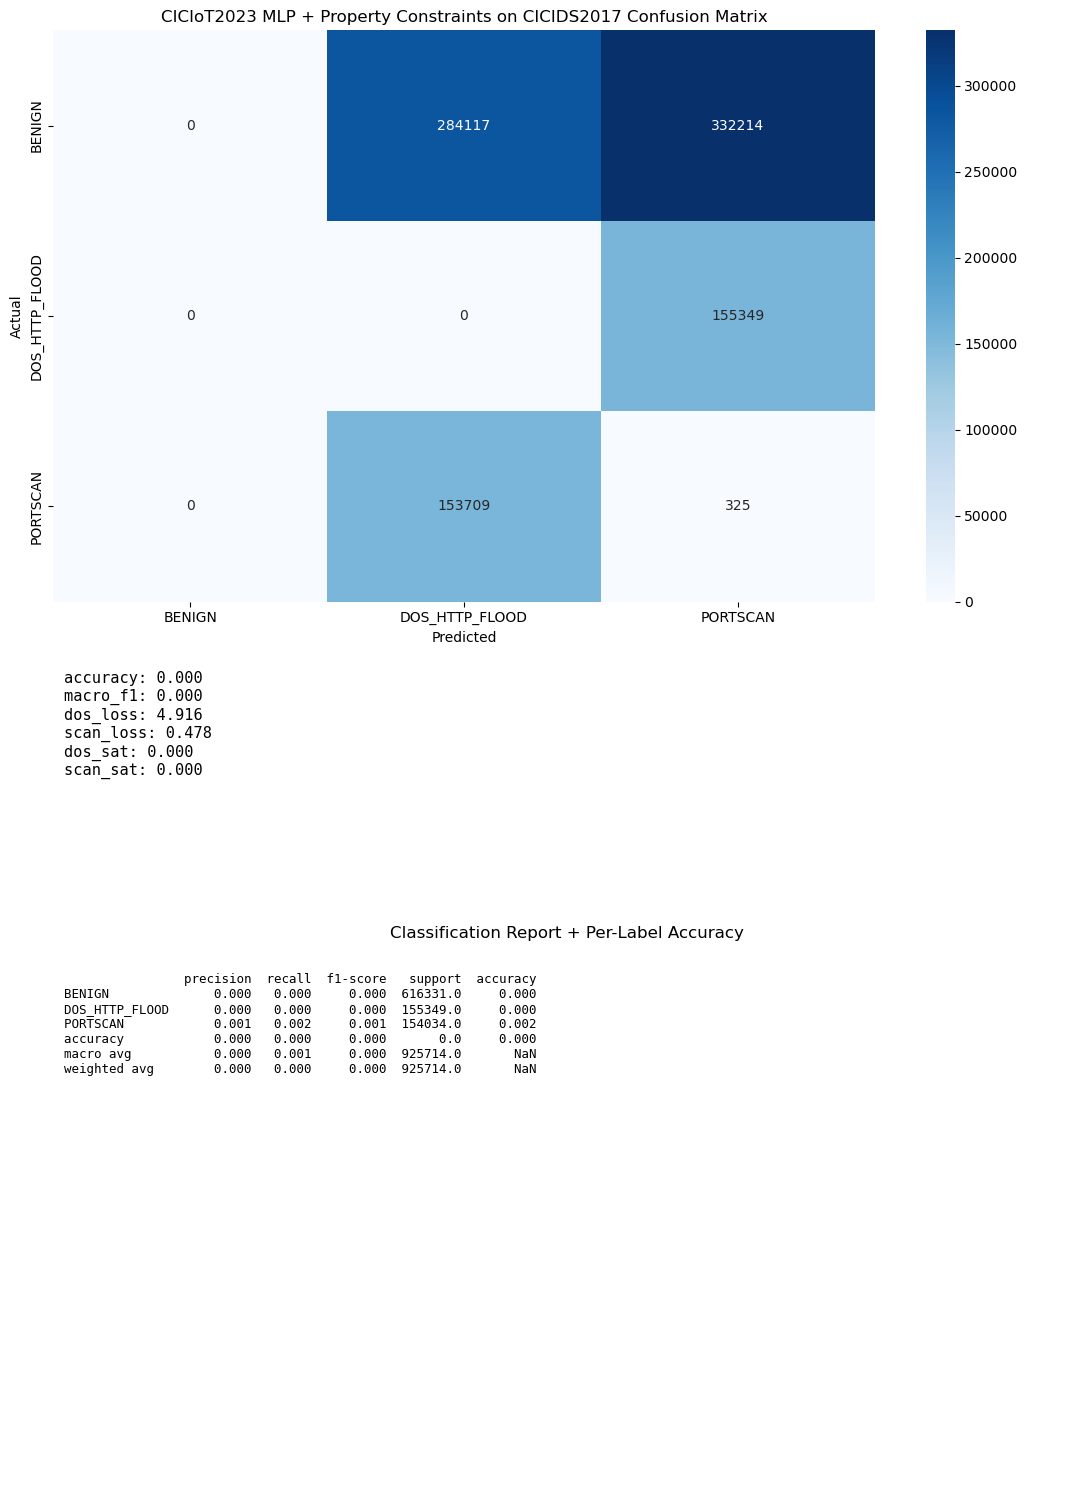


========== RUN bs524_lr0.0005_ldos0.5_lscan0.5_pgd3_step0.01 ==========
PGD steps=3 restarts=1 step_size=tensor([0.0100], device='cuda:0')
class_counts: [19166  8145 12125]
class_weights: tensor([0.6081, 1.4308, 0.9611], device='cuda:0')
run=bs524_lr0.0005_ldos0.5_lscan0.5_pgd3_step0.01 epoch=1 val_attack_f1=0.6751 val_acc=0.4996 val_score=2.2537
run=bs524_lr0.0005_ldos0.5_lscan0.5_pgd3_step0.01 epoch=2 val_attack_f1=0.8440 val_acc=0.8297 val_score=3.3889
run=bs524_lr0.0005_ldos0.5_lscan0.5_pgd3_step0.01 epoch=3 val_attack_f1=0.8375 val_acc=0.8254 val_score=3.3573
run=bs524_lr0.0005_ldos0.5_lscan0.5_pgd3_step0.01 epoch=4 val_attack_f1=0.7414 val_acc=0.7451 val_score=3.1345
run=bs524_lr0.0005_ldos0.5_lscan0.5_pgd3_step0.01 epoch=5 val_attack_f1=0.8438 val_acc=0.8170 val_score=3.4210
run=bs524_lr0.0005_ldos0.5_lscan0.5_pgd3_step0.01 epoch=6 val_attack_f1=0.8522 val_acc=0.8210 val_score=3.4875
run=bs524_lr0.0005_ldos0.5_lscan0.5_pgd3_step0.01 epoch=7 val_attack_f1=0.8293 val_acc=0.8412 v

KeyboardInterrupt: 

In [31]:
all_results = []
best_grid_score = -float("inf")
best_grid_result = None
best_grid_state = None

param_grid = product(
    BATCH_SIZES,
    LEARNING_RATES,
    LAMBDA_DOS_LIST,
    LAMBDA_SCANS,
    PGD_STEPS_LIST,
    PGD_STEP_SIZE_LIST,
)

for run_num, (
    batch_size,
    learning_rate,
    lambda_dos,
    lambda_scan,
    pgd_steps,
    pgd_step_size,
) in enumerate(param_grid, start=1):

    params = {
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "lambda_dos": lambda_dos,
        "lambda_scan": lambda_scan,
        "pgd_steps": pgd_steps,
        "pgd_step_size": pgd_step_size,
    }

    start_time = time.time()

    try:
        result, state = run_single_config(params)
        result["runtime_seconds"] = time.time() - start_time
        result["status"] = "ok"

    except Exception as e:
        result = {
            "run_id": make_run_id(params),
            "params": params,
            "status": "failed",
            "error": repr(e),
            "runtime_seconds": time.time() - start_time,
        }
        state = None
        print(f"FAILED: {result['run_id']}")
        print(repr(e))

    all_results.append(result)

    pd.DataFrame(all_results).to_csv(
        RESULTS_DIR / "grid_search_results.csv",
        index=False,
    )

    if result["status"] == "ok" and result["final_score"] > best_grid_score:
        best_grid_score = result["final_score"]
        best_grid_result = result
        best_grid_state = copy.deepcopy(state)
        best_cross_cmfig = result["cross_cmfig"]

        save_property_model(
            model,
            RESULTS_DIR / "best_property_model.joblib",
            features=FEATURE_COLS,
            model_type="mlp",
            scaler=scaler,
        )

        with open(RESULTS_DIR / "best_hyperparameters.json", "w") as f:
            json.dump(best_grid_result, f, indent=2)

        print("\nNEW BEST")
        print(json.dumps(best_grid_result, indent=2))
        best_cross_cmfig.savefig(RESULTS_DIR / "best_cross_conf_mat.png", dpi=300, bbox_inches="tight")
        best_cross_cmfig.show()
        print(f"Saved plot to: {RESULTS_DIR / 'best_cross_conf_mat.png'}")

        

results_df = pd.DataFrame(all_results)
results_df.sort_values("final_score", ascending=False).to_csv(
    RESULTS_DIR / "grid_search_results_sorted.csv",
    index=False,
)

print("Best grid score:", best_grid_score)
print(json.dumps(best_grid_result, indent=2))